# Imports

In [1]:
import os
import copy
import warnings
import itertools
import datetime as dt
import pandas as pd
import numpy as np
import random # Usado para random.sample e random.shuffle
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf
from dataclasses import dataclass, field
from typing import List, Dict, Optional
from scipy.stats import norm, skew, kurtosis, truncnorm # Importar diretamente as funções
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
from scipy.optimize import curve_fit
from statsmodels.graphics.gofplots import qqplot
from multiprocessing import Pool
import random
import traceback # Importar para printar o traceback em caso de erro

# Importar nas classes quando usar função standalone

warnings.filterwarnings("ignore")

In [2]:
!git clone https://github.com/gilbertogilfgp/Mercado-Artificial-Fiis.git
%cd /content/Mercado-Artificial-Fiis

import sys
sys.path.append('/content/Mercado-Artificial-Fiis')

!pip install numpy pandas matplotlib scipy statsmodels yfinance seaborn

from src.simulacao import simular_mercado_e_plotar

Cloning into 'Mercado-Artificial-Fiis'...
remote: Enumerating objects: 199, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 199 (delta 1), reused 0 (delta 0), pack-reused 193 (from 2)
Receiving objects: 100% (199/199), 12.72 MiB | 11.10 MiB/s, done.
Resolving deltas: 100% (100/100), done.
/content/Mercado-Artificial-Fiis


In [3]:
from src.simulacao import simular_mercado_e_plotar, plotar_resultado, SIM_PARAMS

In [4]:
from src.agentes import Agente, gerar_literacia_financeira
from src.ativos import FII, Imovel
from src.mercado import Mercado, BancoCentral, Midia

In [5]:
parametros_sistema = pd.read_csv('/content/Mercado-Artificial-Fiis/notebooks/dados/parametros_sistema_calibrados.csv').to_numpy()[0]

parametros_sistema

array([0.84822756, 0.69540723, 0.87855894, 0.15595803, 0.07548527])

# Experimento

In [6]:
"""
KNN — Similaridade entre Simulação e IFIX Histórico
Tese: Um Modelo Baseado em Agentes para o Mercado de FIIs Brasileiro

Uso:
    resultado = encontrar_periodo_similar(sim_id=42)
    resultado = encontrar_periodo_similar(sim_id=42, k=5, tau_percentil=95, plotar=True)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.neighbors import NearestNeighbors

# =============================================================================
# CARREGAMENTO DOS DADOS (executado uma vez ao importar o módulo)
# =============================================================================

W = 60  # tamanho da janela em dias

# --- IFIX ---
_url = "https://docs.google.com/spreadsheets/d/1Ijr7MuSuCHXgDLv-xhEktMWeyEQsmjd6/export?format=csv"
_df = pd.read_csv(_url, index_col="Date", parse_dates=True, dayfirst=True)
_df.index = pd.to_datetime(_df.index, format='%Y-%m-%d')
_df["Close"] = (
    _df["Close"].astype(str)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
    .astype(float)
)
_df = _df.sort_index(ascending=True)
_df["log_return"] = np.log(_df["Close"] / _df["Close"].shift(1))
_df = _df.dropna()

IFIX_RETURNS = _df["log_return"].values
IFIX_DATES   = _df.index

# --- Simulações ---
DF_SIM = pd.read_csv(
    '/content/Mercado-Artificial-Fiis/notebooks/dados/simulacoes_validacao_60_dias.csv'
)

print(f"[KNN] IFIX carregado: {len(IFIX_RETURNS)} dias")
print(f"[KNN] Simulações disponíveis: {DF_SIM['simulacao'].nunique()}")
print(f"[KNN] IDs: {sorted(DF_SIM['simulacao'].unique())}")

# =============================================================================
# FUNÇÕES AUXILIARES
# =============================================================================

def _normalize(w: np.ndarray) -> np.ndarray:
    """Z-score por janela. Tolerante a desvio zero."""
    std = w.std()
    return (w - w.mean()) / std if std > 1e-10 else w - w.mean()


def _build_historical_corpus(returns: np.ndarray, W: int):
    """
    Constrói o corpus de janelas deslizantes do IFIX.
    Retorna:
        H        : array (N_H, W) normalizado
        H_raw    : array (N_H, W) bruto
        H_starts : lista de índices de início
    """
    H, H_raw, H_starts = [], [], []
    for i in range(len(returns) - W + 1):
        w = returns[i:i + W]
        H.append(_normalize(w))
        H_raw.append(w)
        H_starts.append(i)
    return np.array(H), np.array(H_raw), H_starts


def _build_sim_window(sim_id: int, df_sim: pd.DataFrame, W: int):
    """
    Extrai os últimos W retornos de uma simulação específica.
    Retorna:
        w_norm : vetor normalizado (entra no KNN)
        w_raw  : vetor bruto (para plotagem)
    """
    grupo = df_sim[df_sim['simulacao'] == sim_id].sort_values('dia')
    retornos = grupo['log_return'].dropna().values
    if len(retornos) < W:
        raise ValueError(
            f"Simulação {sim_id} tem apenas {len(retornos)} retornos válidos "
            f"(mínimo necessário: {W})."
        )
    w_raw = retornos[-W:]
    return _normalize(w_raw), w_raw


def _calcular_tau(H: np.ndarray, k: int, percentil: float) -> tuple:
    """
    Calcula o limiar τ a partir da distribuição intra-histórica.
    Retorna τ e o array d_ref (para plotagem da distribuição).
    """
    knn = NearestNeighbors(n_neighbors=k + 1, metric='euclidean', algorithm='ball_tree')
    knn.fit(H)
    dists, _ = knn.kneighbors(H)
    d_ref = dists[:, 1:].mean(axis=1)   # exclui distância 0 (si mesmo)
    tau   = np.percentile(d_ref, percentil)
    return tau, d_ref, knn

# =============================================================================
# FUNÇÃO PRINCIPAL
# =============================================================================

def encontrar_periodo_similar(
    sim_id      : int,
    k           : int   = 5,
    tau_percentil: float = 95,
    plotar      : bool  = True,
    salvar_fig  : str   = None,
) -> dict:
    """
    Para uma simulação específica, encontra o período histórico do IFIX
    com maior similaridade estrutural aos seus últimos 60 retornos.

    Parâmetros
    ----------
    sim_id        : ID da simulação (coluna 'simulacao' do CSV)
    k             : número de vizinhos do KNN (padrão: 5)
    tau_percentil : percentil para definir o limiar τ (padrão: 95)
    plotar        : se True, exibe o gráfico comparativo
    salvar_fig    : caminho para salvar a figura (ex: '/content/fig.png')
                    Se None, não salva.

    Retorna
    -------
    dict com:
        sim_id            : ID da simulação
        distancia_media   : distância média KNN ao período mais similar
        tau               : limiar de referência
        abaixo_tau        : bool — simulação é indistinguível do histórico?
        data_inicio       : data de início da janela histórica mais similar
        data_fim          : data de fim da janela histórica mais similar
        retornos_sim      : array com os últimos 60 retornos simulados (bruto)
        retornos_hist     : array com os 60 retornos históricos correspondentes
    """

    # 1. Corpus histórico
    H, H_raw, H_starts = _build_historical_corpus(IFIX_RETURNS, W)

    # 2. Janela da simulação solicitada
    sim_norm, sim_raw = _build_sim_window(sim_id, DF_SIM, W)

    # 3. Limiar τ
    tau, d_ref, _ = _calcular_tau(H, k, tau_percentil)

    # 4. KNN: simulação vs. corpus histórico
    knn = NearestNeighbors(n_neighbors=k, metric='euclidean', algorithm='ball_tree')
    knn.fit(H)
    dists, indices = knn.kneighbors(sim_norm.reshape(1, -1))

    d_sim       = dists[0].mean()        # distância média aos k vizinhos
    idx_vizinho = indices[0, 0]          # vizinho mais próximo (1º)

    # 5. Período histórico correspondente
    start_hist = H_starts[idx_vizinho]
    date_ini   = IFIX_DATES[start_hist]
    date_fim   = IFIX_DATES[start_hist + W - 1]
    hist_raw   = H_raw[idx_vizinho]

    abaixo_tau = bool(d_sim <= tau)

    # 6. Impressão do resultado
    print("\n" + "=" * 57)
    print(f"RESULTADO — Simulação {sim_id}")
    print("=" * 57)
    print(f"  Vizinhos k:                    {k}")
    print(f"  Limiar τ (P{int(tau_percentil):02d} intra-hist.): {tau:.6f}")
    print(f"  Distância média KNN:           {d_sim:.6f}")
    print(f"  Indistinguível do histórico?   {'SIM ✓' if abaixo_tau else 'NÃO ✗'}")
    print(f"  Período mais similar no IFIX:  "
          f"{date_ini.strftime('%d/%m/%Y')} – {date_fim.strftime('%d/%m/%Y')}")
    print("=" * 57)

    # 7. Visualização
    if plotar:
        _plotar(
            sim_id      = sim_id,
            sim_raw     = sim_raw,
            hist_raw    = hist_raw,
            d_ref       = d_ref,
            d_sim       = d_sim,
            tau         = tau,
            tau_pct     = tau_percentil,
            date_ini    = date_ini,
            date_fim    = date_fim,
            k           = k,
            salvar_fig  = salvar_fig,
        )

    return {
        "sim_id"          : sim_id,
        "distancia_media" : d_sim,
        "tau"             : tau,
        "abaixo_tau"      : abaixo_tau,
        "data_inicio"     : date_ini,
        "data_fim"        : date_fim,
        "retornos_sim"    : sim_raw,
        "retornos_hist"   : hist_raw,
    }


# =============================================================================
# FUNÇÃO DE VISUALIZAÇÃO — TEMA BRANCO
# =============================================================================

def _plotar(sim_id, sim_raw, hist_raw, d_ref, d_sim, tau, tau_pct,
            date_ini, date_fim, k, salvar_fig):

    c_sim  = '#1565C0'   # azul escuro  — simulado
    c_hist = '#B71C1C'   # vermelho     — histórico
    c_tau  = '#E65100'   # laranja      — limiar
    c_best = '#2E7D32'   # verde        — melhor simulação
    c_grid = '#E0E0E0'   # cinza claro  — grade
    c_bg   = 'white'
    c_fig  = '#F5F5F5'
    dias   = np.arange(1, W + 1)

    sim_norm  = _normalize(sim_raw)
    hist_norm = _normalize(hist_raw)

    fig = plt.figure(figsize=(16, 11))
    fig.patch.set_facecolor(c_fig)
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.35)

    def _estilizar(ax, titulo):
        ax.set_facecolor(c_bg)
        ax.set_title(titulo, color='#212121', fontsize=11, pad=8, fontweight='bold')
        ax.tick_params(colors='#424242')
        ax.grid(color=c_grid, lw=0.7, linestyle='--')
        for sp in ax.spines.values():
            sp.set_edgecolor('#BDBDBD')
            sp.set_linewidth(0.8)
        ax.xaxis.label.set_color('#424242')
        ax.yaxis.label.set_color('#424242')

    # --- Painel A: distribuição de distâncias --------------------------------
    ax0 = fig.add_subplot(gs[0, :])
    ax0.hist(d_ref, bins=80, color='#90A4AE', alpha=0.75,
             label='Dist. intra-histórica (IFIX)')
    ax0.axvline(tau,   color=c_tau,  lw=2.0, ls='--',
                label=f'Limiar τ = {tau:.4f}  (P{int(tau_pct)} histórico)')
    ax0.axvline(d_sim, color=c_best, lw=2.0, ls='-',
                label=f'Simulação {sim_id}  =  {d_sim:.4f}')
    _estilizar(ax0, f'Distribuição das Distâncias KNN (k={k})  —  Referência Histórica IFIX')
    ax0.set_xlabel('Distância Euclidiana Média aos Vizinhos Históricos')
    ax0.set_ylabel('Frequência')
    ax0.legend(facecolor=c_bg, edgecolor='#BDBDBD', fontsize=10,
               labelcolor='#212121')

    # --- Painel B: retornos simulados (bruto) --------------------------------
    ax1 = fig.add_subplot(gs[1, 0])
    ax1.plot(dias, sim_raw, color=c_sim, lw=1.6)
    ax1.axhline(0, color='#9E9E9E', lw=0.8, ls='--')
    _estilizar(ax1, f'Últimos {W} Retornos  —  Simulação {sim_id}')
    ax1.set_xlabel('Dia (relativo ao final da simulação)')
    ax1.set_ylabel('Log-retorno')

    # --- Painel C: retornos históricos (bruto) -------------------------------
    ax2 = fig.add_subplot(gs[1, 1])
    ax2.plot(dias, hist_raw, color=c_hist, lw=1.6)
    ax2.axhline(0, color='#9E9E9E', lw=0.8, ls='--')
    _estilizar(ax2,
        f'Período Histórico Mais Similar\n'
        f'{date_ini.strftime("%d/%m/%Y")} – {date_fim.strftime("%d/%m/%Y")}')
    ax2.set_xlabel('Dia da Janela')
    ax2.set_ylabel('Log-retorno')

    # --- Painel D: sobreposição normalizada ----------------------------------
    ax3 = fig.add_subplot(gs[2, :])
    ax3.plot(dias, sim_norm,  color=c_sim,  lw=1.8,
             label=f'Simulação {sim_id} (normalizado)')
    ax3.plot(dias, hist_norm, color=c_hist, lw=1.8, ls='--',
             label=f'IFIX {date_ini.strftime("%d/%m/%Y")} (normalizado)')
    ax3.fill_between(dias, sim_norm, hist_norm, alpha=0.10, color='#9E9E9E',
                     label=f'Diferença pontual  |  dist. média = {d_sim:.4f}')
    ax3.axhline(0, color='#9E9E9E', lw=0.8, ls='--')
    _estilizar(ax3, 'Sobreposição Normalizada (z-score)  —  Par Mais Similar')
    ax3.set_xlabel('Dia da Janela')
    ax3.set_ylabel('Retorno Normalizado')
    ax3.legend(facecolor=c_bg, edgecolor='#BDBDBD', fontsize=9,
               labelcolor='#212121')

    # --- Título geral --------------------------------------------------------
    status = "✓  Indistinguível do Histórico" if d_sim <= tau else "✗  Fora do Limiar Histórico"
    fig.suptitle(
        f'KNN — Simulação {sim_id}  ×  IFIX Histórico\n'
        f'{status}   |   k={k}   |   W={W} dias   |   τ={tau:.4f}  (P{int(tau_pct)})',
        color='#212121', fontsize=13, fontweight='bold', y=1.01
    )

    plt.tight_layout()

    if salvar_fig:
        plt.savefig(salvar_fig, dpi=150, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
        print(f"[KNN] Figura salva em: {salvar_fig}")

    plt.show()







[KNN] IFIX carregado: 2730 dias
[KNN] Simulações disponíveis: 700
[KNN] IDs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int6


RESULTADO — Simulação 120
  Vizinhos k:                    5
  Limiar τ (P95 intra-hist.): 8.556300
  Distância média KNN:           8.180226
  Indistinguível do histórico?   SIM ✓
  Período mais similar no IFIX:  03/05/2018 – 27/07/2018


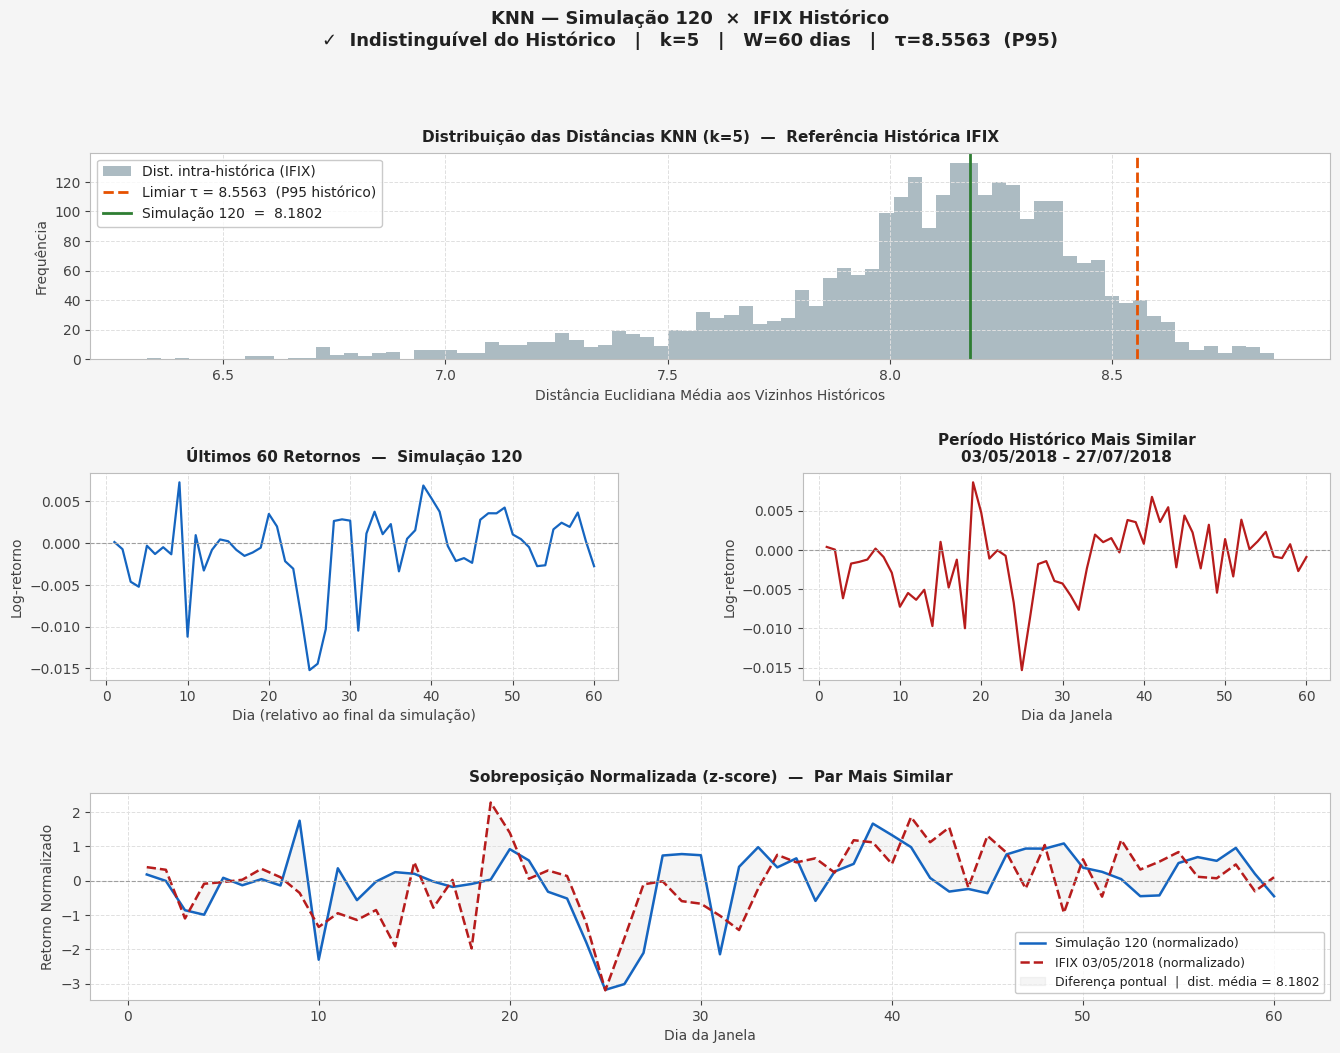

In [7]:
resultado = encontrar_periodo_similar(sim_id=120)

In [8]:
"""
KNN — Similaridade entre Simulação e IFIX Histórico
Tese: Um Modelo Baseado em Agentes para o Mercado de FIIs Brasileiro

Funções:
    encontrar_periodo_similar(sim_id)  → analisa uma simulação específica
    calcular_cobertura_knn()           → % de simulações abaixo de τ (KNN-CR)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.neighbors import NearestNeighbors

# =============================================================================
# CARREGAMENTO DOS DADOS (executado uma vez ao importar o módulo)
# =============================================================================

W = 60

_url = "https://docs.google.com/spreadsheets/d/1Ijr7MuSuCHXgDLv-xhEktMWeyEQsmjd6/export?format=csv"
_df = pd.read_csv(_url, index_col="Date", parse_dates=True, dayfirst=True)
_df.index = pd.to_datetime(_df.index, format='%Y-%m-%d')
_df["Close"] = (
    _df["Close"].astype(str)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
    .astype(float)
)
_df = _df.sort_index(ascending=True)
_df["log_return"] = np.log(_df["Close"] / _df["Close"].shift(1))
_df = _df.dropna()

IFIX_RETURNS = _df["log_return"].values
IFIX_DATES   = _df.index

DF_SIM = pd.read_csv(
    '/content/Mercado-Artificial-Fiis/notebooks/dados/simulacoes_validacao_60_dias.csv'
)

print(f"[KNN] IFIX carregado: {len(IFIX_RETURNS)} dias")
print(f"[KNN] Simulações disponíveis: {DF_SIM['simulacao'].nunique()}")

# =============================================================================
# FUNÇÕES AUXILIARES (internas)
# =============================================================================

def _normalize(w: np.ndarray) -> np.ndarray:
    std = w.std()
    return (w - w.mean()) / std if std > 1e-10 else w - w.mean()


def _build_historical_corpus(returns: np.ndarray, W: int):
    H, H_raw, H_starts = [], [], []
    for i in range(len(returns) - W + 1):
        w = returns[i:i + W]
        H.append(_normalize(w))
        H_raw.append(w)
        H_starts.append(i)
    return np.array(H), np.array(H_raw), H_starts


def _build_sim_window(sim_id: int, df_sim: pd.DataFrame, W: int):
    grupo    = df_sim[df_sim['simulacao'] == sim_id].sort_values('dia')
    retornos = grupo['log_return'].dropna().values
    if len(retornos) < W:
        raise ValueError(
            f"Simulação {sim_id} tem apenas {len(retornos)} retornos válidos "
            f"(mínimo necessário: {W})."
        )
    w_raw = retornos[-W:]
    return _normalize(w_raw), w_raw


def _calcular_tau(H: np.ndarray, k: int, percentil: float):
    knn = NearestNeighbors(n_neighbors=k + 1, metric='euclidean', algorithm='ball_tree')
    knn.fit(H)
    dists, _ = knn.kneighbors(H)
    d_ref    = dists[:, 1:].mean(axis=1)
    tau      = np.percentile(d_ref, percentil)
    return tau, d_ref


def _build_knn_sim(H: np.ndarray, k: int):
    knn = NearestNeighbors(n_neighbors=k, metric='euclidean', algorithm='ball_tree')
    knn.fit(H)
    return knn


# =============================================================================
# FUNÇÃO 1 — análise de uma simulação específica
# =============================================================================

def encontrar_periodo_similar(
    sim_id        : int,
    k             : int   = 5,
    tau_percentil : float = 95,
    plotar        : bool  = True,
    salvar_fig    : str   = None,
) -> dict:
    """
    Encontra o período histórico do IFIX mais similar aos últimos
    60 retornos de uma simulação específica.
    """

    H, H_raw, H_starts = _build_historical_corpus(IFIX_RETURNS, W)
    sim_norm, sim_raw  = _build_sim_window(sim_id, DF_SIM, W)
    tau, d_ref         = _calcular_tau(H, k, tau_percentil)

    knn            = _build_knn_sim(H, k)
    dists, indices = knn.kneighbors(sim_norm.reshape(1, -1))

    d_sim       = dists[0].mean()
    idx_vizinho = indices[0, 0]

    start_hist = H_starts[idx_vizinho]
    date_ini   = IFIX_DATES[start_hist]
    date_fim   = IFIX_DATES[start_hist + W - 1]
    hist_raw   = H_raw[idx_vizinho]
    abaixo_tau = bool(d_sim <= tau)

    print("\n" + "=" * 57)
    print(f"RESULTADO — Simulação {sim_id}")
    print("=" * 57)
    print(f"  Vizinhos k:                    {k}")
    print(f"  Limiar τ (P{int(tau_percentil):02d} intra-hist.): {tau:.6f}")
    print(f"  Distância média KNN:           {d_sim:.6f}")
    print(f"  Indistinguível do histórico?   {'SIM ✓' if abaixo_tau else 'NÃO ✗'}")
    print(f"  Período mais similar no IFIX:  "
          f"{date_ini.strftime('%d/%m/%Y')} – {date_fim.strftime('%d/%m/%Y')}")
    print("=" * 57)

    if plotar:
        _plotar(sim_id, sim_raw, hist_raw, d_ref, d_sim, tau,
                tau_percentil, date_ini, date_fim, k, salvar_fig)

    return {
        "sim_id"          : sim_id,
        "distancia_media" : d_sim,
        "tau"             : tau,
        "abaixo_tau"      : abaixo_tau,
        "data_inicio"     : date_ini,
        "data_fim"        : date_fim,
        "retornos_sim"    : sim_raw,
        "retornos_hist"   : hist_raw,
    }


# =============================================================================
# FUNÇÃO 2 — cobertura KNN sobre todas as simulações (KNN-CR)
# =============================================================================

def calcular_cobertura_knn(
    k             : int   = 5,
    tau_percentil : float = 95,
    plotar        : bool  = True,
    salvar_fig    : str   = None,
) -> dict:
    """
    Calcula a Taxa de Cobertura KNN (KNN-CR): percentual de simulações
    cujos últimos 60 retornos são indistinguíveis do histórico do IFIX.

    Parâmetros
    ----------
    k             : número de vizinhos (padrão: 5)
    tau_percentil : percentil do limiar τ (padrão: 95)
    plotar        : se True, exibe gráfico de cobertura
    salvar_fig    : caminho para salvar a figura

    Retorna
    -------
    dict com: knn_cr, n_abaixo, n_total, tau, resultados (DataFrame)
    """

    # 1. Corpus histórico e limiar (calculados uma vez)
    H, H_raw, H_starts = _build_historical_corpus(IFIX_RETURNS, W)
    tau, d_ref         = _calcular_tau(H, k, tau_percentil)
    knn                = _build_knn_sim(H, k)

    # 2. Iterar sobre todas as simulações
    registros  = []
    ids_validos = sorted(DF_SIM['simulacao'].unique())

    for sim_id in ids_validos:
        try:
            sim_norm, sim_raw = _build_sim_window(sim_id, DF_SIM, W)
        except ValueError:
            continue   # simulação muito curta — ignorar

        dists, indices = knn.kneighbors(sim_norm.reshape(1, -1))
        d_sim          = dists[0].mean()
        idx_vizinho    = indices[0, 0]
        start_hist     = H_starts[idx_vizinho]
        date_ini       = IFIX_DATES[start_hist]
        date_fim       = IFIX_DATES[start_hist + W - 1]

        registros.append({
            "sim_id"         : sim_id,
            "distancia"      : d_sim,
            "abaixo_tau"     : d_sim <= tau,
            "data_inicio"    : date_ini,
            "data_fim"       : date_fim,
        })

    # 3. Resultados agregados
    df_res   = pd.DataFrame(registros)
    n_total  = len(df_res)
    n_abaixo = df_res["abaixo_tau"].sum()
    knn_cr   = n_abaixo / n_total if n_total > 0 else 0.0

    print("\n" + "=" * 57)
    print("TAXA DE COBERTURA KNN (KNN-CR)")
    print("=" * 57)
    print(f"  Simulações avaliadas:          {n_total}")
    print(f"  Vizinhos k:                    {k}")
    print(f"  Limiar τ (P{int(tau_percentil):02d} intra-hist.): {tau:.6f}")
    print(f"  Simulações abaixo de τ:        {n_abaixo} / {n_total}")
    print(f"  KNN-CR:                        {knn_cr:.2%}")
    print("=" * 57)

    if plotar:
        _plotar_cobertura(df_res, d_ref, tau, tau_percentil,
                          knn_cr, k, salvar_fig)

    return {
        "knn_cr"     : knn_cr,
        "n_abaixo"   : n_abaixo,
        "n_total"    : n_total,
        "tau"        : tau,
        "resultados" : df_res,
    }


# =============================================================================
# VISUALIZAÇÃO — simulação individual
# =============================================================================

def _plotar(sim_id, sim_raw, hist_raw, d_ref, d_sim, tau, tau_pct,
            date_ini, date_fim, k, salvar_fig):

    c_sim  = '#1565C0'
    c_hist = '#B71C1C'
    c_tau  = '#E65100'
    c_best = '#2E7D32'
    c_grid = '#E0E0E0'
    c_bg   = 'white'
    c_fig  = '#F5F5F5'
    dias   = np.arange(1, W + 1)

    sim_norm  = _normalize(sim_raw)
    hist_norm = _normalize(hist_raw)

    fig = plt.figure(figsize=(16, 11))
    fig.patch.set_facecolor(c_fig)
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.35)

    def _est(ax, titulo):
        ax.set_facecolor(c_bg)
        ax.set_title(titulo, color='#212121', fontsize=11, pad=8, fontweight='bold')
        ax.tick_params(colors='#424242')
        ax.grid(color=c_grid, lw=0.7, linestyle='--')
        for sp in ax.spines.values():
            sp.set_edgecolor('#BDBDBD')
            sp.set_linewidth(0.8)
        ax.xaxis.label.set_color('#424242')
        ax.yaxis.label.set_color('#424242')

    ax0 = fig.add_subplot(gs[0, :])
    ax0.hist(d_ref, bins=80, color='#90A4AE', alpha=0.75,
             label='Dist. intra-histórica (IFIX)')
    ax0.axvline(tau,   color=c_tau,  lw=2.0, ls='--',
                label=f'Limiar τ = {tau:.4f}  (P{int(tau_pct)} histórico)')
    ax0.axvline(d_sim, color=c_best, lw=2.0, ls='-',
                label=f'Simulação {sim_id}  =  {d_sim:.4f}')
    _est(ax0, f'Distribuição das Distâncias KNN (k={k})  —  Referência Histórica IFIX')
    ax0.set_xlabel('Distância Euclidiana Média aos Vizinhos Históricos')
    ax0.set_ylabel('Frequência')
    ax0.legend(facecolor=c_bg, edgecolor='#BDBDBD', fontsize=10, labelcolor='#212121')

    ax1 = fig.add_subplot(gs[1, 0])
    ax1.plot(dias, sim_raw, color=c_sim, lw=1.6)
    ax1.axhline(0, color='#9E9E9E', lw=0.8, ls='--')
    _est(ax1, f'Últimos {W} Retornos  —  Simulação {sim_id}')
    ax1.set_xlabel('Dia (relativo ao final da simulação)')
    ax1.set_ylabel('Log-retorno')

    ax2 = fig.add_subplot(gs[1, 1])
    ax2.plot(dias, hist_raw, color=c_hist, lw=1.6)
    ax2.axhline(0, color='#9E9E9E', lw=0.8, ls='--')
    _est(ax2, f'Período Histórico Mais Similar\n'
              f'{date_ini.strftime("%d/%m/%Y")} – {date_fim.strftime("%d/%m/%Y")}')
    ax2.set_xlabel('Dia da Janela')
    ax2.set_ylabel('Log-retorno')

    ax3 = fig.add_subplot(gs[2, :])
    ax3.plot(dias, sim_norm,  color=c_sim,  lw=1.8,
             label=f'Simulação {sim_id} (normalizado)')
    ax3.plot(dias, hist_norm, color=c_hist, lw=1.8, ls='--',
             label=f'IFIX {date_ini.strftime("%d/%m/%Y")} (normalizado)')
    ax3.fill_between(dias, sim_norm, hist_norm, alpha=0.10, color='#9E9E9E',
                     label=f'Diferença pontual  |  dist. média = {d_sim:.4f}')
    ax3.axhline(0, color='#9E9E9E', lw=0.8, ls='--')
    _est(ax3, 'Sobreposição Normalizada (z-score)  —  Par Mais Similar')
    ax3.set_xlabel('Dia da Janela')
    ax3.set_ylabel('Retorno Normalizado')
    ax3.legend(facecolor=c_bg, edgecolor='#BDBDBD', fontsize=9, labelcolor='#212121')

    status = "✓  Indistinguível do Histórico" if d_sim <= tau else "✗  Fora do Limiar Histórico"
    fig.suptitle(
        f'KNN — Simulação {sim_id}  ×  IFIX Histórico\n'
        f'{status}   |   k={k}   |   W={W} dias   |   τ={tau:.4f}  (P{int(tau_pct)})',
        color='#212121', fontsize=13, fontweight='bold', y=1.01
    )
    plt.tight_layout()

    if salvar_fig:
        plt.savefig(salvar_fig, dpi=150, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
        print(f"[KNN] Figura salva em: {salvar_fig}")
    plt.show()


# =============================================================================
# VISUALIZAÇÃO — cobertura global
# =============================================================================

def _plotar_cobertura(df_res, d_ref, tau, tau_pct, knn_cr, k, salvar_fig):

    c_abaixo = '#1565C0'
    c_acima  = '#B71C1C'
    c_tau    = '#E65100'
    c_grid   = '#E0E0E0'
    c_bg     = 'white'
    c_fig    = '#F5F5F5'

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor(c_fig)

    def _est(ax, titulo):
        ax.set_facecolor(c_bg)
        ax.set_title(titulo, color='#212121', fontsize=11, pad=8, fontweight='bold')
        ax.tick_params(colors='#424242')
        ax.grid(color=c_grid, lw=0.7, linestyle='--')
        for sp in ax.spines.values():
            sp.set_edgecolor('#BDBDBD')
            sp.set_linewidth(0.8)
        ax.xaxis.label.set_color('#424242')
        ax.yaxis.label.set_color('#424242')

    # Painel A — distribuição das distâncias simuladas vs. histórico
    ax0 = axes[0]
    ax0.hist(d_ref, bins=80, color='#90A4AE', alpha=0.65,
             label='Dist. intra-histórica (IFIX)')
    ax0.hist(df_res['distancia'], bins=40, color=c_abaixo, alpha=0.70,
             label='Dist. simulações')
    ax0.axvline(tau, color=c_tau, lw=2.0, ls='--',
                label=f'τ = {tau:.4f}  (P{int(tau_pct)})')
    _est(ax0, f'Distribuição das Distâncias KNN (k={k})')
    ax0.set_xlabel('Distância Euclidiana Média (k vizinhos)')
    ax0.set_ylabel('Frequência')
    ax0.legend(facecolor=c_bg, edgecolor='#BDBDBD', fontsize=9, labelcolor='#212121')

    # Painel B — distância por simulação com τ marcado
    ax1 = axes[1]
    cores = [c_abaixo if v else c_acima for v in df_res['abaixo_tau']]
    ax1.bar(df_res['sim_id'], df_res['distancia'], color=cores,
            width=0.8, alpha=0.85)
    ax1.axhline(tau, color=c_tau, lw=2.0, ls='--',
                label=f'τ = {tau:.4f}')
    _est(ax1, f'Distância por Simulação  —  KNN-CR = {knn_cr:.1%}')
    ax1.set_xlabel('ID da Simulação')
    ax1.set_ylabel('Distância Média KNN')

    # Legenda manual para as barras
    from matplotlib.patches import Patch
    legenda = [
        Patch(facecolor=c_abaixo, label=f'Abaixo de τ  ({df_res["abaixo_tau"].sum()})'),
        Patch(facecolor=c_acima,  label=f'Acima de τ   ({(~df_res["abaixo_tau"]).sum()})'),
    ]
    ax1.legend(handles=legenda, facecolor=c_bg, edgecolor='#BDBDBD',
               fontsize=9, labelcolor='#212121')

    fig.suptitle(
        f'Taxa de Cobertura KNN (KNN-CR)  —  {knn_cr:.1%} das simulações abaixo de τ\n'
        f'k={k}   |   W={W} dias   |   τ={tau:.4f}  (P{int(tau_pct)})',
        color='#212121', fontsize=13, fontweight='bold', y=1.02
    )
    plt.tight_layout()

    if salvar_fig:
        plt.savefig(salvar_fig, dpi=150, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
        print(f"[KNN] Figura salva em: {salvar_fig}")
    plt.show()




[KNN] IFIX carregado: 2730 dias
[KNN] Simulações disponíveis: 700



RESULTADO — Simulação 700
  Vizinhos k:                    5
  Limiar τ (P95 intra-hist.): 8.556300
  Distância média KNN:           8.260017
  Indistinguível do histórico?   SIM ✓
  Período mais similar no IFIX:  11/10/2024 – 10/01/2025


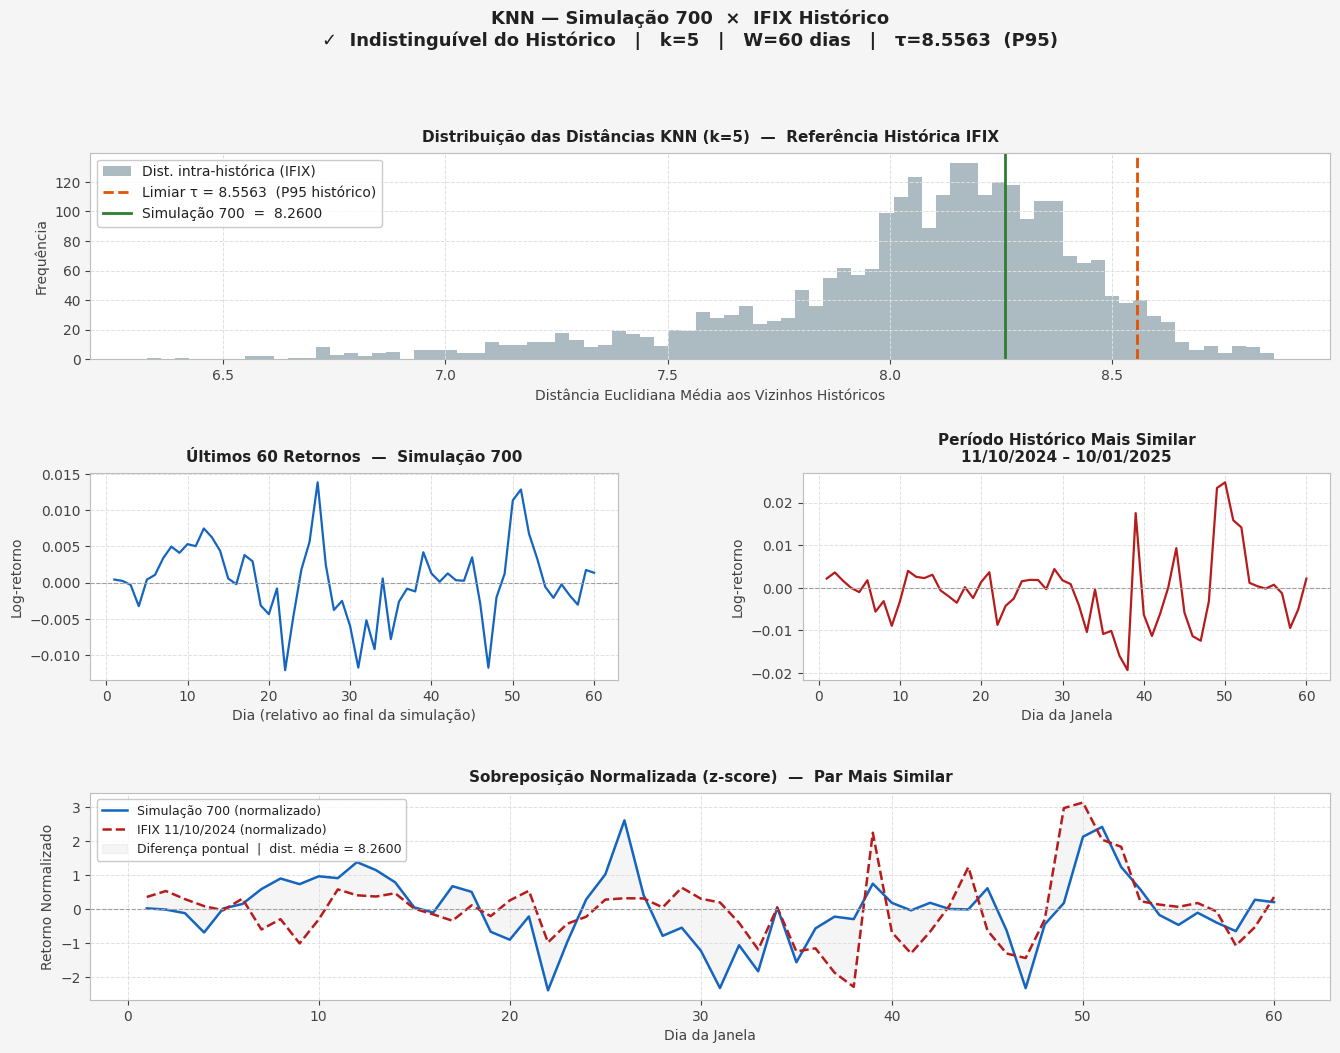


TAXA DE COBERTURA KNN (KNN-CR)
  Simulações avaliadas:          700
  Vizinhos k:                    5
  Limiar τ (P95 intra-hist.): 8.556300
  Simulações abaixo de τ:        675 / 700
  KNN-CR:                        96.43%


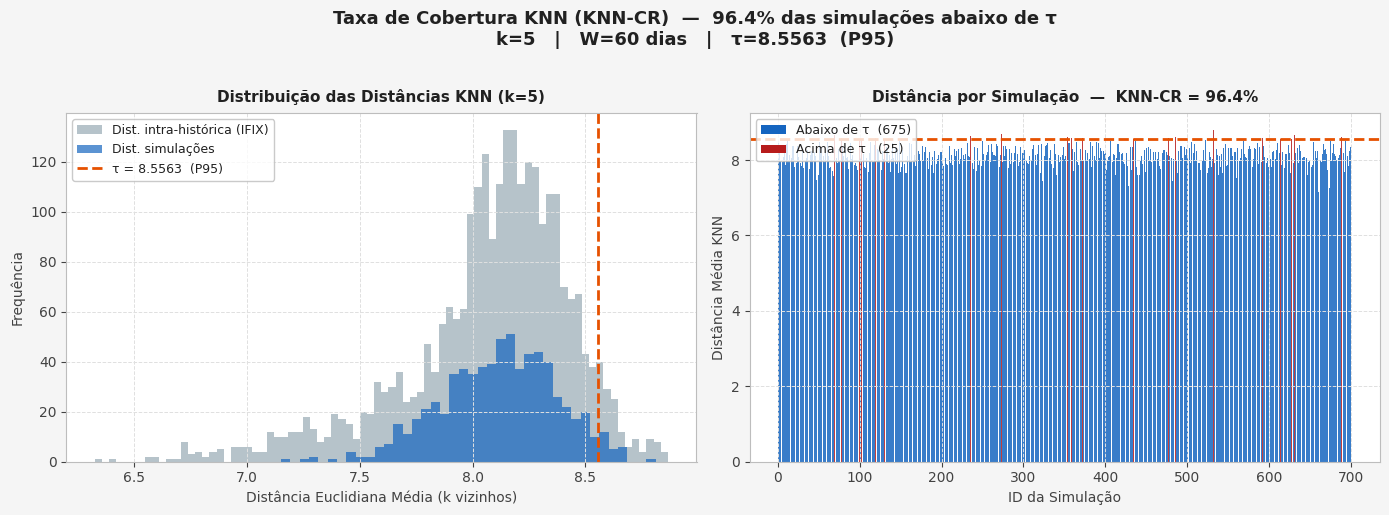

In [9]:
# =============================================================================
# EXEMPLO DE USO
# =============================================================================

if __name__ == "__main__":

    # Análise de uma simulação específica
    resultado = encontrar_periodo_similar(sim_id=700)

    # Cobertura global sobre todas as simulações
    cobertura = calcular_cobertura_knn(k=5, tau_percentil=95, plotar=True)

    # Acessar o DataFrame com todas as simulações
    # print(cobertura['resultados'])

In [10]:
"""
KNN — Similaridade entre Simulação e IFIX Histórico
Tese: Um Modelo Baseado em Agentes para o Mercado de FIIs Brasileiro

Funções:
    encontrar_periodo_similar(sim_id)  → analisa uma simulação específica
    calcular_cobertura_knn()           → % de simulações abaixo de τ (KNN-CR)
    plotar_similaridade(sim_id)        → preços simulados vs. IFIX (2 eixos y)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.neighbors import NearestNeighbors

# =============================================================================
# CARREGAMENTO DOS DADOS (executado uma vez ao importar o módulo)
# =============================================================================

W = 60

_url = "https://docs.google.com/spreadsheets/d/1Ijr7MuSuCHXgDLv-xhEktMWeyEQsmjd6/export?format=csv"
_df = pd.read_csv(_url, index_col="Date", parse_dates=True, dayfirst=True)
_df.index = pd.to_datetime(_df.index, format='%Y-%m-%d')
_df["Close"] = (
    _df["Close"].astype(str)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
    .astype(float)
)
_df = _df.sort_index(ascending=True)
_df["log_return"] = np.log(_df["Close"] / _df["Close"].shift(1))
_df = _df.dropna()

IFIX_RETURNS = _df["log_return"].values
IFIX_PRICES  = _df["Close"].values        # preços brutos — usados em plotar_similaridade
IFIX_DATES   = _df.index

DF_SIM = pd.read_csv(
    '/content/Mercado-Artificial-Fiis/notebooks/dados/simulacoes_validacao_60_dias.csv'
)

print(f"[KNN] IFIX carregado: {len(IFIX_RETURNS)} dias")
print(f"[KNN] Simulações disponíveis: {DF_SIM['simulacao'].nunique()}")

# =============================================================================
# FUNÇÕES AUXILIARES (internas)
# =============================================================================

def _normalize(w: np.ndarray) -> np.ndarray:
    std = w.std()
    return (w - w.mean()) / std if std > 1e-10 else w - w.mean()


def _build_historical_corpus(returns: np.ndarray, W: int):
    H, H_raw, H_starts = [], [], []
    for i in range(len(returns) - W + 1):
        w = returns[i:i + W]
        H.append(_normalize(w))
        H_raw.append(w)
        H_starts.append(i)
    return np.array(H), np.array(H_raw), H_starts


def _build_sim_window(sim_id: int, df_sim: pd.DataFrame, W: int):
    grupo    = df_sim[df_sim['simulacao'] == sim_id].sort_values('dia')
    retornos = grupo['log_return'].dropna().values
    if len(retornos) < W:
        raise ValueError(
            f"Simulação {sim_id} tem apenas {len(retornos)} retornos válidos "
            f"(mínimo necessário: {W})."
        )
    w_raw = retornos[-W:]
    return _normalize(w_raw), w_raw


def _calcular_tau(H: np.ndarray, k: int, percentil: float):
    knn = NearestNeighbors(n_neighbors=k + 1, metric='euclidean', algorithm='ball_tree')
    knn.fit(H)
    dists, _ = knn.kneighbors(H)
    d_ref    = dists[:, 1:].mean(axis=1)
    tau      = np.percentile(d_ref, percentil)
    return tau, d_ref


def _build_knn_sim(H: np.ndarray, k: int):
    knn = NearestNeighbors(n_neighbors=k, metric='euclidean', algorithm='ball_tree')
    knn.fit(H)
    return knn


def _estilizar(ax, titulo):
    """Aplica tema branco padronizado a um eixo."""
    ax.set_facecolor('white')
    ax.set_title(titulo, color='#212121', fontsize=11, pad=8, fontweight='bold')
    ax.tick_params(colors='#424242')
    ax.grid(color='#E0E0E0', lw=0.7, linestyle='--')
    for sp in ax.spines.values():
        sp.set_edgecolor('#BDBDBD')
        sp.set_linewidth(0.8)
    ax.xaxis.label.set_color('#424242')
    ax.yaxis.label.set_color('#424242')


def _encontrar_vizinho(sim_id: int, k: int = 5, tau_percentil: float = 95):
    """
    Núcleo compartilhado entre encontrar_periodo_similar e plotar_similaridade.
    Retorna todos os dados necessários para análise e plotagem.
    """
    H, H_raw, H_starts = _build_historical_corpus(IFIX_RETURNS, W)
    sim_norm, sim_raw  = _build_sim_window(sim_id, DF_SIM, W)
    tau, d_ref         = _calcular_tau(H, k, tau_percentil)

    knn            = _build_knn_sim(H, k)
    dists, indices = knn.kneighbors(sim_norm.reshape(1, -1))

    d_sim       = dists[0].mean()
    idx_vizinho = indices[0, 0]
    start_hist  = H_starts[idx_vizinho]

    return {
        "sim_norm"   : sim_norm,
        "sim_raw"    : sim_raw,
        "hist_raw"   : H_raw[idx_vizinho],
        "d_ref"      : d_ref,
        "d_sim"      : d_sim,
        "tau"        : tau,
        "start_hist" : start_hist,
        "date_ini"   : IFIX_DATES[start_hist],
        "date_fim"   : IFIX_DATES[start_hist + W - 1],
        "abaixo_tau" : d_sim <= tau,
    }


# =============================================================================
# FUNÇÃO 1 — análise de uma simulação específica
# =============================================================================

def encontrar_periodo_similar(
    sim_id        : int,
    k             : int   = 5,
    tau_percentil : float = 95,
    plotar        : bool  = True,
    salvar_fig    : str   = None,
) -> dict:
    """
    Encontra o período histórico do IFIX mais similar aos últimos
    60 retornos de uma simulação específica.
    """
    r = _encontrar_vizinho(sim_id, k, tau_percentil)

    print("\n" + "=" * 57)
    print(f"RESULTADO — Simulação {sim_id}")
    print("=" * 57)
    print(f"  Vizinhos k:                    {k}")
    print(f"  Limiar τ (P{int(tau_percentil):02d} intra-hist.): {r['tau']:.6f}")
    print(f"  Distância média KNN:           {r['d_sim']:.6f}")
    print(f"  Indistinguível do histórico?   {'SIM ✓' if r['abaixo_tau'] else 'NÃO ✗'}")
    print(f"  Período mais similar no IFIX:  "
          f"{r['date_ini'].strftime('%d/%m/%Y')} – {r['date_fim'].strftime('%d/%m/%Y')}")
    print("=" * 57)

    if plotar:
        _plotar(sim_id, r, k, tau_percentil, salvar_fig)

    return {
        "sim_id"          : sim_id,
        "distancia_media" : r["d_sim"],
        "tau"             : r["tau"],
        "abaixo_tau"      : r["abaixo_tau"],
        "data_inicio"     : r["date_ini"],
        "data_fim"        : r["date_fim"],
        "retornos_sim"    : r["sim_raw"],
        "retornos_hist"   : r["hist_raw"],
    }


# =============================================================================
# FUNÇÃO 2 — cobertura KNN sobre todas as simulações (KNN-CR)
# =============================================================================

def calcular_cobertura_knn(
    k             : int   = 5,
    tau_percentil : float = 95,
    plotar        : bool  = True,
    salvar_fig    : str   = None,
) -> dict:
    """
    Calcula a Taxa de Cobertura KNN (KNN-CR): percentual de simulações
    cujos últimos 60 retornos são indistinguíveis do histórico do IFIX.
    """
    H, H_raw, H_starts = _build_historical_corpus(IFIX_RETURNS, W)
    tau, d_ref         = _calcular_tau(H, k, tau_percentil)
    knn                = _build_knn_sim(H, k)

    registros = []
    for sim_id in sorted(DF_SIM['simulacao'].unique()):
        try:
            sim_norm, sim_raw = _build_sim_window(sim_id, DF_SIM, W)
        except ValueError:
            continue
        dists, indices = knn.kneighbors(sim_norm.reshape(1, -1))
        d_sim          = dists[0].mean()
        start_hist     = H_starts[indices[0, 0]]
        registros.append({
            "sim_id"      : sim_id,
            "distancia"   : d_sim,
            "abaixo_tau"  : d_sim <= tau,
            "data_inicio" : IFIX_DATES[start_hist],
            "data_fim"    : IFIX_DATES[start_hist + W - 1],
        })

    df_res   = pd.DataFrame(registros)
    n_total  = len(df_res)
    n_abaixo = df_res["abaixo_tau"].sum()
    knn_cr   = n_abaixo / n_total if n_total > 0 else 0.0

    print("\n" + "=" * 57)
    print("TAXA DE COBERTURA KNN (KNN-CR)")
    print("=" * 57)
    print(f"  Simulações avaliadas:          {n_total}")
    print(f"  Vizinhos k:                    {k}")
    print(f"  Limiar τ (P{int(tau_percentil):02d} intra-hist.): {tau:.6f}")
    print(f"  Simulações abaixo de τ:        {n_abaixo} / {n_total}")
    print(f"  KNN-CR:                        {knn_cr:.2%}")
    print("=" * 57)

    if plotar:
        _plotar_cobertura(df_res, d_ref, tau, tau_percentil, knn_cr, k, salvar_fig)

    return {
        "knn_cr"     : knn_cr,
        "n_abaixo"   : n_abaixo,
        "n_total"    : n_total,
        "tau"        : tau,
        "resultados" : df_res,
    }


# =============================================================================
# FUNÇÃO 3 — preços simulados vs. IFIX em 2 eixos y independentes
# =============================================================================

def plotar_similaridade(
    sim_id        : int,
    k             : int   = 5,
    tau_percentil : float = 95,
    salvar_fig    : str   = None,
) -> None:
    """
    Plota os preços dos últimos 60 dias da simulação e os preços reais
    do IFIX no período histórico mais similar, em dois eixos y distintos.

    Eixo esquerdo (azul)  : preço simulado reconstituído, base 100
    Eixo direito  (vermelho): preço real do IFIX em pontos
    """
    r = _encontrar_vizinho(sim_id, k, tau_percentil)

    # --- Preço simulado: reconstitui a partir dos log-retornos (base 100) ---
    precos_sim = np.empty(W)
    precos_sim[0] = 100.0
    for i in range(1, W):
        precos_sim[i] = precos_sim[i - 1] * np.exp(r["sim_raw"][i])

    # --- Preço real do IFIX na janela identificada ---------------------------
    start       = r["start_hist"]
    precos_hist = IFIX_PRICES[start : start + W]
    dias        = np.arange(1, W + 1)

    # --- Cores e layout ------------------------------------------------------
    c_sim  = '#1565C0'
    c_hist = '#B71C1C'
    c_tau  = '#E65100'
    c_fig  = '#F5F5F5'
    status = "✓  Indistinguível" if r["abaixo_tau"] else "✗  Fora do Limiar"

    fig, ax1 = plt.subplots(figsize=(13, 5))
    fig.patch.set_facecolor(c_fig)
    ax1.set_facecolor('white')

    # Eixo esquerdo — simulação
    ln1, = ax1.plot(dias, precos_sim, color=c_sim, lw=2.0,
                    label=f'Simulação {sim_id} — preço (base 100)  [eixo esq.]')
    ax1.set_xlabel('Dia da Janela (últimos 60 períodos)', color='#424242', fontsize=10)
    ax1.set_ylabel('Preço Simulado (base 100)', color=c_sim, fontsize=10)
    ax1.tick_params(axis='y', colors=c_sim)
    ax1.tick_params(axis='x', colors='#424242')
    ax1.spines['left'].set_edgecolor(c_sim)
    ax1.spines['left'].set_linewidth(1.5)
    ax1.spines['top'].set_edgecolor('#BDBDBD')
    ax1.spines['bottom'].set_edgecolor('#BDBDBD')
    ax1.grid(color='#E0E0E0', lw=0.7, linestyle='--')

    # Eixo direito — IFIX real
    ax2 = ax1.twinx()
    ln2, = ax2.plot(dias, precos_hist, color=c_hist, lw=2.0, linestyle='--',
                    label=f'IFIX  {r["date_ini"].strftime("%d/%m/%Y")} – '
                          f'{r["date_fim"].strftime("%d/%m/%Y")}  [eixo dir.]')
    ax2.set_ylabel('IFIX (pontos)', color=c_hist, fontsize=10)
    ax2.tick_params(axis='y', colors=c_hist)
    ax2.spines['right'].set_edgecolor(c_hist)
    ax2.spines['right'].set_linewidth(1.5)
    ax2.spines['top'].set_visible(False)
    ax2.spines['bottom'].set_visible(False)

    # Legenda unificada
    lns  = [ln1, ln2]
    labs = [l.get_label() for l in lns]
    ax1.legend(lns, labs, facecolor='white', edgecolor='#BDBDBD',
               fontsize=9, labelcolor='#212121', loc='best')

    # Título
    ax1.set_title(
        f'Similaridade KNN  —  Simulação {sim_id}  ×  IFIX Histórico\n'
        f'{status}   |   dist. = {r["d_sim"]:.4f}   |   '
        f'τ = {r["tau"]:.4f} (P{int(tau_percentil)})   |   k = {k}',
        color='#212121', fontsize=11, fontweight='bold', pad=10
    )

    plt.tight_layout()

    if salvar_fig:
        plt.savefig(salvar_fig, dpi=150, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
        print(f"[KNN] Figura salva em: {salvar_fig}")

    plt.show()


# =============================================================================
# VISUALIZAÇÃO — retornos (interna de encontrar_periodo_similar)
# =============================================================================

def _plotar(sim_id, r, k, tau_pct, salvar_fig):

    c_sim  = '#1565C0'
    c_hist = '#B71C1C'
    c_tau  = '#E65100'
    c_best = '#2E7D32'
    dias   = np.arange(1, W + 1)

    sim_norm  = _normalize(r["sim_raw"])
    hist_norm = _normalize(r["hist_raw"])

    fig = plt.figure(figsize=(16, 11))
    fig.patch.set_facecolor('#F5F5F5')
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.35)

    ax0 = fig.add_subplot(gs[0, :])
    ax0.hist(r["d_ref"], bins=80, color='#90A4AE', alpha=0.75,
             label='Dist. intra-histórica (IFIX)')
    ax0.axvline(r["tau"],   color=c_tau,  lw=2.0, ls='--',
                label=f'Limiar τ = {r["tau"]:.4f}  (P{int(tau_pct)} histórico)')
    ax0.axvline(r["d_sim"], color=c_best, lw=2.0, ls='-',
                label=f'Simulação {sim_id}  =  {r["d_sim"]:.4f}')
    _estilizar(ax0, f'Distribuição das Distâncias KNN (k={k})  —  Referência Histórica IFIX')
    ax0.set_xlabel('Distância Euclidiana Média aos Vizinhos Históricos')
    ax0.set_ylabel('Frequência')
    ax0.legend(facecolor='white', edgecolor='#BDBDBD', fontsize=10, labelcolor='#212121')

    ax1 = fig.add_subplot(gs[1, 0])
    ax1.plot(dias, r["sim_raw"], color=c_sim, lw=1.6)
    ax1.axhline(0, color='#9E9E9E', lw=0.8, ls='--')
    _estilizar(ax1, f'Últimos {W} Retornos  —  Simulação {sim_id}')
    ax1.set_xlabel('Dia (relativo ao final da simulação)')
    ax1.set_ylabel('Log-retorno')

    ax2 = fig.add_subplot(gs[1, 1])
    ax2.plot(dias, r["hist_raw"], color=c_hist, lw=1.6)
    ax2.axhline(0, color='#9E9E9E', lw=0.8, ls='--')
    _estilizar(ax2, f'Período Histórico Mais Similar\n'
                    f'{r["date_ini"].strftime("%d/%m/%Y")} – {r["date_fim"].strftime("%d/%m/%Y")}')
    ax2.set_xlabel('Dia da Janela')
    ax2.set_ylabel('Log-retorno')

    ax3 = fig.add_subplot(gs[2, :])
    ax3.plot(dias, sim_norm,  color=c_sim,  lw=1.8,
             label=f'Simulação {sim_id} (normalizado)')
    ax3.plot(dias, hist_norm, color=c_hist, lw=1.8, ls='--',
             label=f'IFIX {r["date_ini"].strftime("%d/%m/%Y")} (normalizado)')
    ax3.fill_between(dias, sim_norm, hist_norm, alpha=0.10, color='#9E9E9E',
                     label=f'Diferença pontual  |  dist. média = {r["d_sim"]:.4f}')
    ax3.axhline(0, color='#9E9E9E', lw=0.8, ls='--')
    _estilizar(ax3, 'Sobreposição Normalizada (z-score)  —  Par Mais Similar')
    ax3.set_xlabel('Dia da Janela')
    ax3.set_ylabel('Retorno Normalizado')
    ax3.legend(facecolor='white', edgecolor='#BDBDBD', fontsize=9, labelcolor='#212121')

    status = "✓  Indistinguível do Histórico" if r["abaixo_tau"] else "✗  Fora do Limiar Histórico"
    fig.suptitle(
        f'KNN — Simulação {sim_id}  ×  IFIX Histórico\n'
        f'{status}   |   k={k}   |   W={W} dias   |   τ={r["tau"]:.4f}  (P{int(tau_pct)})',
        color='#212121', fontsize=13, fontweight='bold', y=1.01
    )
    plt.tight_layout()

    if salvar_fig:
        plt.savefig(salvar_fig, dpi=150, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
        print(f"[KNN] Figura salva em: {salvar_fig}")
    plt.show()


# =============================================================================
# VISUALIZAÇÃO — cobertura global
# =============================================================================

def _plotar_cobertura(df_res, d_ref, tau, tau_pct, knn_cr, k, salvar_fig):

    c_abaixo = '#1565C0'
    c_acima  = '#B71C1C'
    c_tau    = '#E65100'

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('#F5F5F5')

    ax0 = axes[0]
    ax0.hist(d_ref, bins=80, color='#90A4AE', alpha=0.65,
             label='Dist. intra-histórica (IFIX)')
    ax0.hist(df_res['distancia'], bins=40, color=c_abaixo, alpha=0.70,
             label='Dist. simulações')
    ax0.axvline(tau, color=c_tau, lw=2.0, ls='--',
                label=f'τ = {tau:.4f}  (P{int(tau_pct)})')
    _estilizar(ax0, f'Distribuição das Distâncias KNN (k={k})')
    ax0.set_xlabel('Distância Euclidiana Média (k vizinhos)')
    ax0.set_ylabel('Frequência')
    ax0.legend(facecolor='white', edgecolor='#BDBDBD', fontsize=9, labelcolor='#212121')

    ax1 = axes[1]
    cores = [c_abaixo if v else c_acima for v in df_res['abaixo_tau']]
    ax1.bar(df_res['sim_id'], df_res['distancia'], color=cores, width=0.8, alpha=0.85)
    ax1.axhline(tau, color=c_tau, lw=2.0, ls='--', label=f'τ = {tau:.4f}')
    _estilizar(ax1, f'Distância por Simulação  —  KNN-CR = {knn_cr:.1%}')
    ax1.set_xlabel('ID da Simulação')
    ax1.set_ylabel('Distância Média KNN')

    from matplotlib.patches import Patch
    legenda = [
        Patch(facecolor=c_abaixo, label=f'Abaixo de τ  ({df_res["abaixo_tau"].sum()})'),
        Patch(facecolor=c_acima,  label=f'Acima de τ   ({(~df_res["abaixo_tau"]).sum()})'),
    ]
    ax1.legend(handles=legenda, facecolor='white', edgecolor='#BDBDBD',
               fontsize=9, labelcolor='#212121')

    fig.suptitle(
        f'Taxa de Cobertura KNN (KNN-CR)  —  {knn_cr:.1%} das simulações abaixo de τ\n'
        f'k={k}   |   W={W} dias   |   τ={tau:.4f}  (P{int(tau_pct)})',
        color='#212121', fontsize=13, fontweight='bold', y=1.02
    )
    plt.tight_layout()

    if salvar_fig:
        plt.savefig(salvar_fig, dpi=150, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
        print(f"[KNN] Figura salva em: {salvar_fig}")
    plt.show()




[KNN] IFIX carregado: 2730 dias
[KNN] Simulações disponíveis: 700


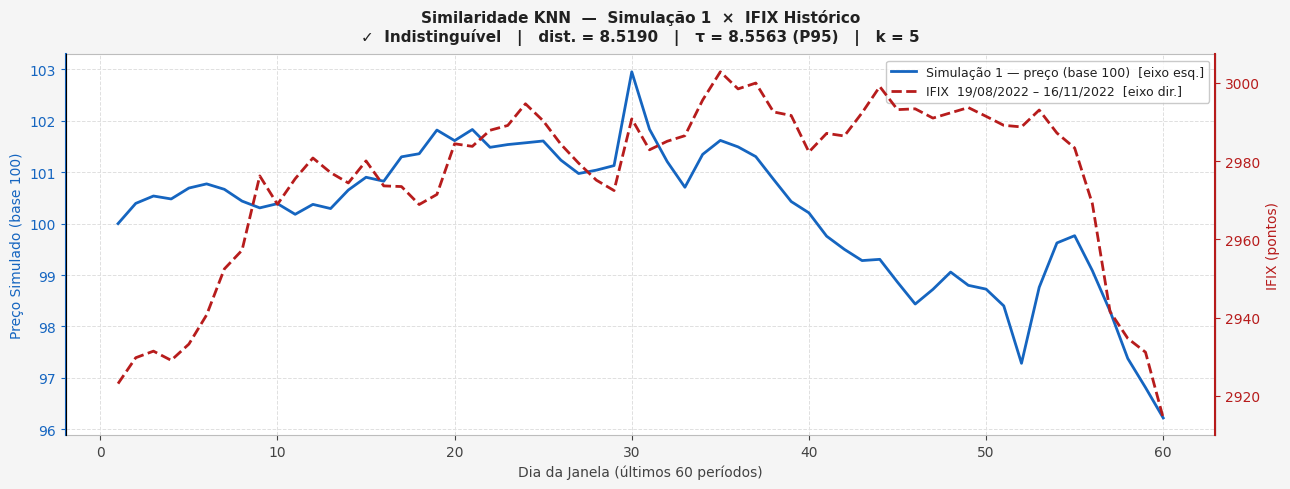

In [21]:
plotar_similaridade(sim_id=1)


RESULTADO — Simulação 1
  Vizinhos k:                    5
  Limiar τ (P95 intra-hist.): 8.556300
  Distância média KNN:           8.518984
  Indistinguível do histórico?   SIM ✓
  Período mais similar no IFIX:  19/08/2022 – 16/11/2022


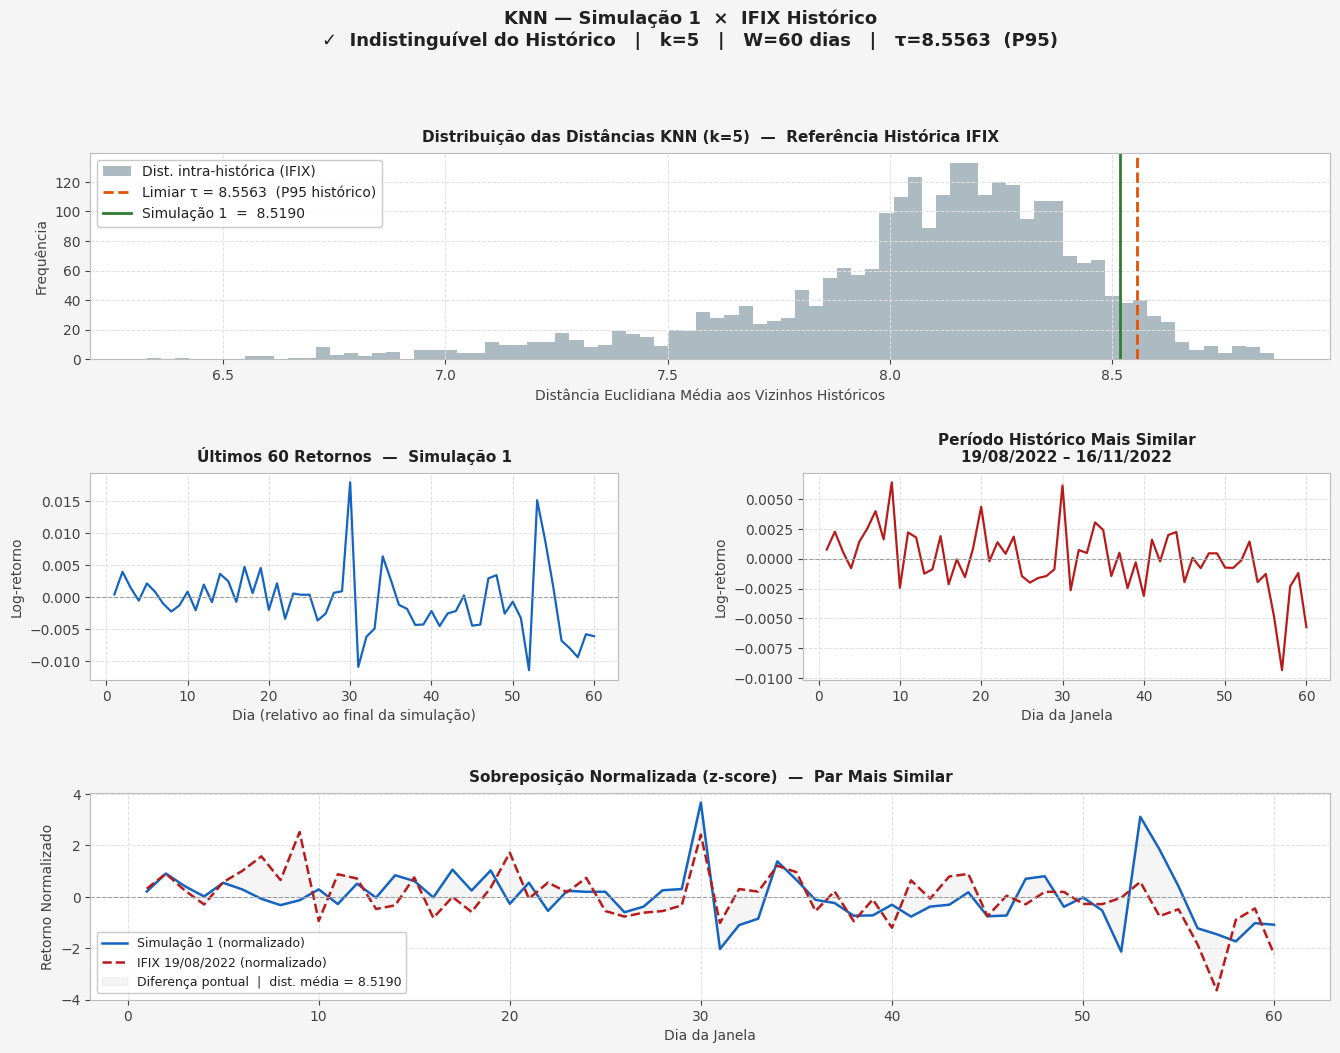

{'sim_id': 1,
 'distancia_media': np.float64(8.51898397576829),
 'tau': np.float64(8.556300369824537),
 'abaixo_tau': np.True_,
 'data_inicio': Timestamp('2022-08-19 00:00:00'),
 'data_fim': Timestamp('2022-11-16 00:00:00'),
 'retornos_sim': array([ 0.00039488,  0.00392972,  0.00142902, -0.00057145,  0.0021098 ,
         0.00080512, -0.00104793, -0.00228089, -0.00131503,  0.00082007,
        -0.00206747,  0.00192722, -0.00081092,  0.00358858,  0.00246449,
        -0.00076199,  0.0046935 ,  0.00059549,  0.0045336 , -0.00202138,
         0.0021267 , -0.00341013,  0.0005299 ,  0.0003362 ,  0.00035079,
        -0.00367518, -0.00257888,  0.00064898,  0.0008802 ,  0.01788505,
        -0.01090543, -0.00620755, -0.00495066,  0.00632944,  0.00268111,
        -0.00123963, -0.00186508, -0.00436739, -0.00430013, -0.00219526,
        -0.00453884, -0.00256705, -0.00220425,  0.00024322, -0.00447885,
        -0.00431871,  0.00289839,  0.00340024, -0.0026078 , -0.00074712,
        -0.00330732, -0.01141

In [22]:
encontrar_periodo_similar(sim_id=1)


TAXA DE COBERTURA KNN (KNN-CR)
  Simulações avaliadas:          700
  Vizinhos k:                    5
  Limiar τ (P95 intra-hist.): 8.556300
  Simulações abaixo de τ:        675 / 700
  KNN-CR:                        96.43%


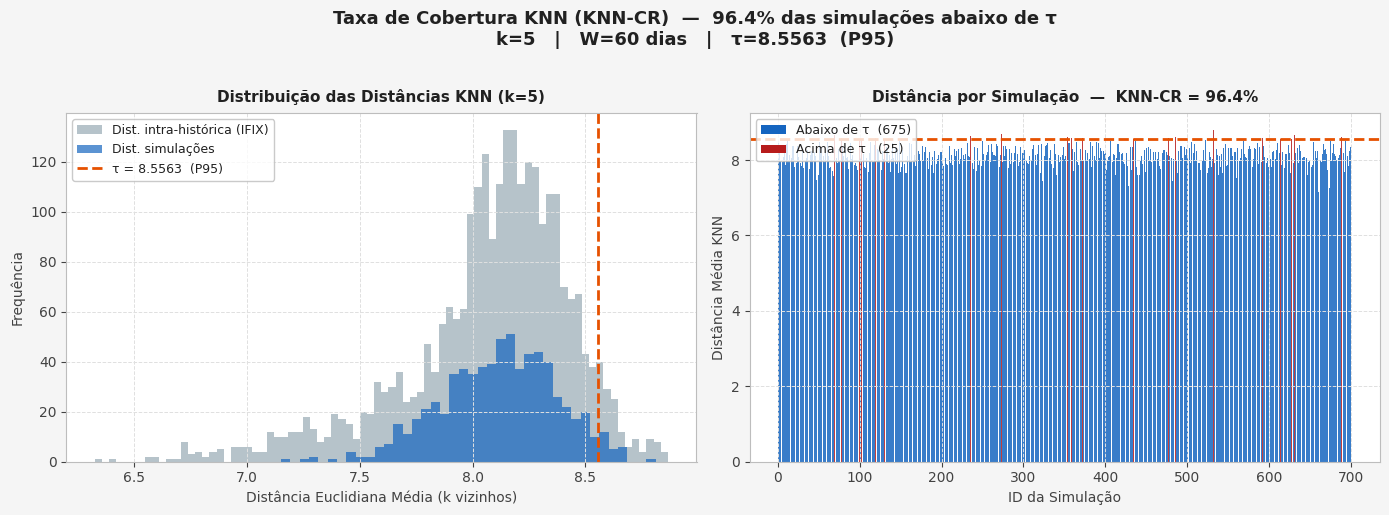

{'knn_cr': np.float64(0.9642857142857143),
 'n_abaixo': np.int64(675),
 'n_total': 700,
 'tau': np.float64(8.556300369824537),
 'resultados':      sim_id  distancia  abaixo_tau data_inicio   data_fim
 0         1   8.518984        True  2022-08-19 2022-11-16
 1         2   8.411324        True  2024-06-17 2024-09-06
 2         3   7.984286        True  2022-05-31 2022-08-23
 3         4   8.061559        True  2021-09-14 2021-12-09
 4         5   8.118840        True  2018-12-06 2019-03-08
 ..      ...        ...         ...         ...        ...
 695     696   8.098807        True  2022-10-03 2022-12-28
 696     697   7.836220        True  2017-02-08 2017-05-09
 697     698   8.240833        True  2025-02-18 2025-05-19
 698     699   8.351966        True  2024-04-26 2024-07-22
 699     700   8.260017        True  2024-10-11 2025-01-10
 
 [700 rows x 5 columns]}

In [13]:
calcular_cobertura_knn(k=5, tau_percentil=95, plotar=True)

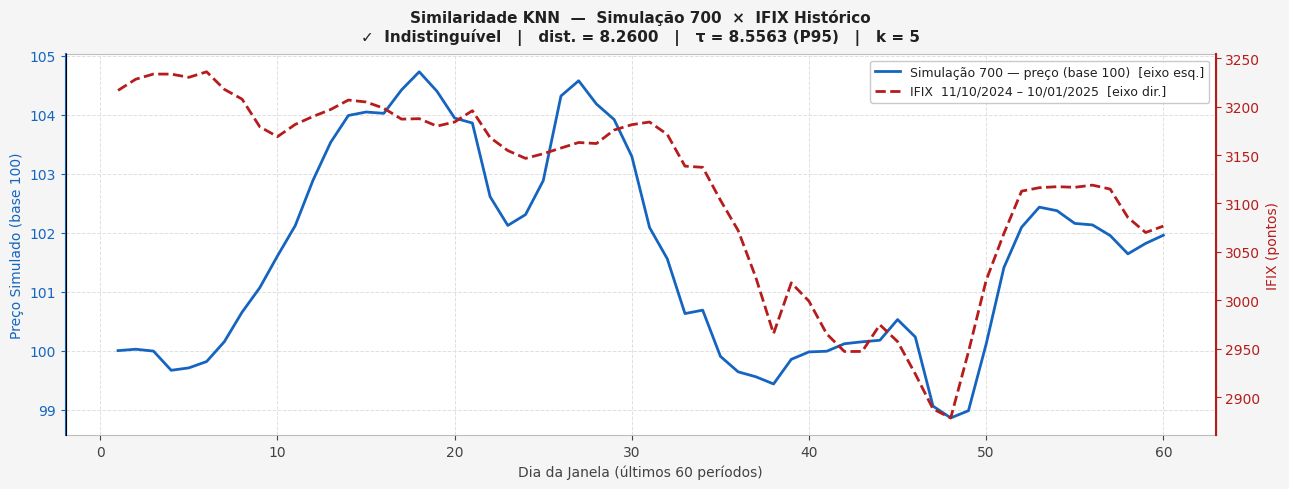

In [14]:
# =============================================================================
# EXEMPLO DE USO
# =============================================================================

if __name__ == "__main__":

    # Preços simulados vs. IFIX em 2 eixos y
    plotar_similaridade(sim_id=700)

    # Análise completa de retornos
    #

    # Cobertura global
    #